
**Lab: Mạng Nơ-ron Nhân tạo (ANN) với PyTorch**

Bai 1: Thay đổi cấu trúc ANN

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

In [16]:
# Sinh dữ liệu lớp 0 (đĩa)
def gen_disk(n, r_max=1.0):

    u = np.random.uniform(0, 1, n)

    theta = np.random.uniform(0, 2*np.pi, n)

    r = r_max * np.sqrt(u)

    return np.column_stack(
        (r*np.cos(theta), r*np.sin(theta))
    )

# Sinh dữ liệu lớp 1 (vành)
def gen_ring(n, r_in=1.5, r_out=2.5):

    u = np.random.uniform(0, 1, n)

    theta = np.random.uniform(0, 2*np.pi, n)

    r = np.sqrt(
        u*(r_out**2 - r_in**2) + r_in**2
    )

    return np.column_stack(
        (r*np.cos(theta), r*np.sin(theta))
    )

# Tạo dữ liệu
n_per_class = 150

X0 = gen_disk(n_per_class)

X1 = gen_ring(n_per_class)

X = np.vstack([X0, X1])

y = np.hstack([
    np.zeros(n_per_class),
    np.ones(n_per_class)
])

# Train/Test split
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Chuyển sang tensor
X_train = torch.FloatTensor(X_train_np)

y_train = torch.FloatTensor(y_train_np).unsqueeze(1)

X_test = torch.FloatTensor(X_test_np)

y_test = torch.FloatTensor(y_test_np).unsqueeze(1)

print("Train:", len(X_train))
print("Test :", len(X_test))

Train: 240
Test : 60


Mô Hình 4 nút ẩn

In [17]:
class ANN_4(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

Mô hình 8 nút ẩn

In [18]:
class ANN_8(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

Mô hình 2 lớp ẩn: 2→8→6→1

In [19]:
class ANN_8_6(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),

            nn.Linear(8, 6),
            nn.ReLU(),

            nn.Linear(6, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

Hàm train 500 epoch

In [20]:
def train(model, epochs=500):

    criterion = nn.BCELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.01
    )

    loss_history = []

    acc_history = []

    for epoch in range(epochs):

        # TRAIN
        model.train()

        optimizer.zero_grad()

        outputs = model(X_train)

        loss = criterion(outputs, y_train)

        loss.backward()

        optimizer.step()

        # TEST
        model.eval()

        with torch.no_grad():

            pred = (model(X_test) > 0.5).float()

            acc = (
                pred == y_test
            ).float().mean().item()

        loss_history.append(loss.item())

        acc_history.append(acc)

    return loss_history, acc_history

=== Kết quả cuối ===
ANN 4 nút   : loss = 0.0364   acc = 98.33%
ANN 8 nút   : loss = 0.0065   acc = 100.00%
ANN 8+6 nút : loss = 0.0004   acc = 100.00%


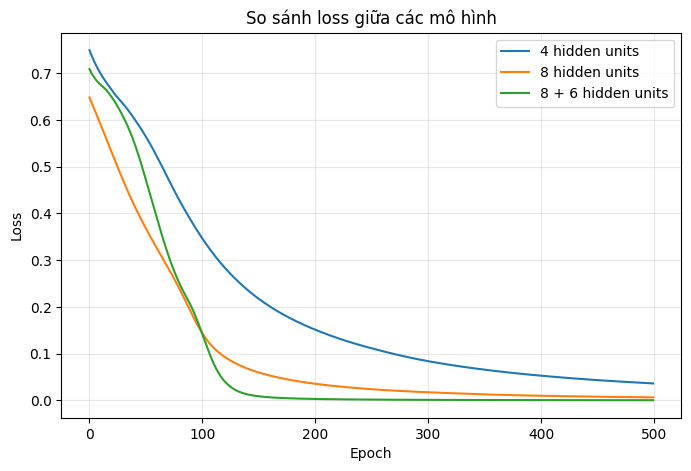

In [21]:
# Khởi tạo model
model_4 = ANN_4()

model_8 = ANN_8()

model_8_6 = ANN_8_6()

# Train
loss_4, acc_4 = train(model_4)

loss_8, acc_8 = train(model_8)

loss_86, acc_86 = train(model_8_6)

# In kết quả
print("=== Kết quả cuối ===")

print(f"ANN 4 nút   : loss = {loss_4[-1]:.4f}   acc = {acc_4[-1]*100:.2f}%")

print(f"ANN 8 nút   : loss = {loss_8[-1]:.4f}   acc = {acc_8[-1]*100:.2f}%")

print(f"ANN 8+6 nút : loss = {loss_86[-1]:.4f}   acc = {acc_86[-1]*100:.2f}%")

# Vẽ đồ thị loss
plt.figure(figsize=(8,5))

plt.plot(loss_4, label='4 hidden units')

plt.plot(loss_8, label='8 hidden units')

plt.plot(loss_86, label='8 + 6 hidden units')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("So sánh loss giữa các mô hình")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

Nhận xét
1. Mô hình lớn hơn có giảm loss nhanh hơn không?
- Có vì: Mạng nhiều nút hơn học nhanh hơn.Loss giảm nhanh hơn ở giai đoạn đầu.
2. Có overfitting không?
- Không vì: Dữ liệu đơn giản
3. Có diminishing returns không?
- Có vì:
-  tăng từ 4 → 8 nút thì cải thiện rõ.
- Tăng tiếp lên 8+6: accuracy tăng ít nhưng model phức tạp hơn nhiều.

**Phần 2: Loss và Optimizer**

Bài 1. Đổi BCELoss thành BCEWithLogitsLoss

In [23]:
class ANN_Logits(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2, 4),

            nn.ReLU(),

            nn.Linear(4, 1)

        )

    def forward(self, x):

        return self.net(x)

In [24]:
# Khởi tạo model
model_logits = ANN_Logits()

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(
    model_logits.parameters(),
    lr=0.01
)

epochs = 500

loss_history_logits = []

acc_history_logits = []

for epoch in range(epochs):

    # =====================
    # TRAIN
    # =====================

    model_logits.train()

    optimizer.zero_grad()

    outputs = model_logits(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    # =====================
    # TEST
    # =====================

    model_logits.eval()

    with torch.no_grad():

        # BCEWithLogitsLoss chưa sigmoid
        probs = torch.sigmoid(
            model_logits(X_test)
        )

        pred = (probs > 0.5).float()

        acc = (
            pred == y_test
        ).float().mean().item()

    # Lưu history
    loss_history_logits.append(loss.item())

    acc_history_logits.append(acc)

    # In kết quả
    if (epoch + 1) % 100 == 0:

        print(
            f"Epoch {epoch+1:3d} | "
            f"loss = {loss.item():.4f} | "
            f"acc = {acc*100:.2f}%"
        )

Epoch 100 | loss = 0.2645 | acc = 98.33%
Epoch 200 | loss = 0.0677 | acc = 100.00%
Epoch 300 | loss = 0.0351 | acc = 100.00%
Epoch 400 | loss = 0.0220 | acc = 100.00%
Epoch 500 | loss = 0.0151 | acc = 100.00%


In [25]:
print("=== Kết quả cuối ===")

print(
    f"Final loss = {loss_history_logits[-1]:.4f}"
)

print(
    f"Final acc  = {acc_history_logits[-1]*100:.2f}%"
)

=== Kết quả cuối ===
Final loss = 0.0151
Final acc  = 100.00%


Bài 2. Đổi Adam thành SGD

In [26]:
# Model cũ
model_sgd = ANN_4()

# Loss function
criterion = nn.BCELoss()

# SGD optimizer
optimizer = optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

epochs = 500

loss_history_sgd = []

acc_history_sgd = []

for epoch in range(epochs):

    # TRAIN
    model_sgd.train()

    optimizer.zero_grad()

    outputs = model_sgd(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    # TEST
    model_sgd.eval()

    with torch.no_grad():

        pred = (
            model_sgd(X_test) > 0.5
        ).float()

        acc = (
            pred == y_test
        ).float().mean().item()

    # Lưu history
    loss_history_sgd.append(loss.item())

    acc_history_sgd.append(acc)

    # In kết quả
    if (epoch + 1) % 100 == 0:

        print(
            f"Epoch {epoch+1:3d} | "
            f"loss = {loss.item():.4f} | "
            f"acc = {acc*100:.2f}%"
        )

Epoch 100 | loss = 0.6000 | acc = 50.00%
Epoch 200 | loss = 0.5403 | acc = 58.33%
Epoch 300 | loss = 0.4587 | acc = 70.00%
Epoch 400 | loss = 0.3633 | acc = 83.33%
Epoch 500 | loss = 0.2397 | acc = 98.33%


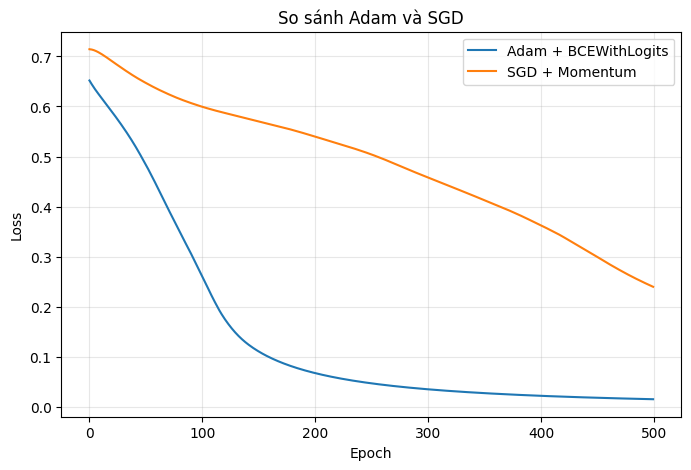

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    loss_history_logits,
    label='Adam + BCEWithLogits'
)

plt.plot(
    loss_history_sgd,
    label='SGD + Momentum'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("So sánh Adam và SGD")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

**Phần 3 — Phân tích sâu**

Bài 1. Thử nhiều Learning Rate: lr ∈ {0.001, 0.01, 0.1}

In [28]:
class ANN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2, 4),

            nn.ReLU(),

            nn.Linear(4, 1),

            nn.Sigmoid()
        )

    def forward(self, x):

        return self.net(x)

In [29]:
def train_lr(lr, epochs=500):

    model = ANN()

    criterion = nn.BCELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    loss_history = []

    for epoch in range(epochs):

        # TRAIN
        model.train()

        optimizer.zero_grad()

        outputs = model(X_train)

        loss = criterion(outputs, y_train)

        loss.backward()

        optimizer.step()

        loss_history.append(loss.item())

    return loss_history

In [30]:
loss_0001 = train_lr(0.001)

loss_001 = train_lr(0.01)

loss_01 = train_lr(0.1)

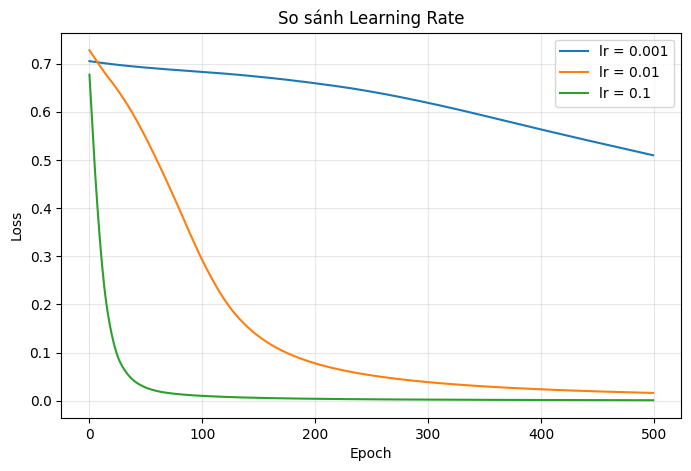

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    loss_0001,
    label='lr = 0.001'
)

plt.plot(
    loss_001,
    label='lr = 0.01'
)

plt.plot(
    loss_01,
    label='lr = 0.1'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("So sánh Learning Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

Nhận xét
Learning rate = 0.001: quá nhỏ,
model học rất chậm,
loss giảm từ từ.

⇒ cần nhiều epoch hơn mới hội tụ.

Learning rate = 0.01: phù hợp,
loss giảm nhanh,
hội tụ ổn định.

⇒ đây thường là learning rate tốt nhất cho bài này.

Learning rate = 0.1: quá lớn,
bước cập nhật quá mạnh,
loss dễ:
dao động,
tăng giảm thất thường,

⇒ model học không ổn định.

Bài 2. Vẽ ranh giới quyết định

In [32]:
def plot_boundary(model, epoch):

    # Tạo lưới điểm
    x_min, x_max = (
        X[:,0].min() - 0.3,
        X[:,0].max() + 0.3
    )

    y_min, y_max = (
        X[:,1].min() - 0.3,
        X[:,1].max() + 0.3
    )

    xx, yy = np.meshgrid(

        np.linspace(x_min, x_max, 200),

        np.linspace(y_min, y_max, 200)
    )

    grid = torch.FloatTensor(
        np.c_[xx.ravel(), yy.ravel()]
    )

    # Predict
    model.eval()

    with torch.no_grad():

        proba = model(grid)

        proba = proba.numpy().reshape(xx.shape)

    # Vẽ
    plt.figure(figsize=(6,6))

    plt.contourf(
        xx,
        yy,
        proba,
        levels=20,
        cmap='coolwarm',
        alpha=0.7
    )

    plt.scatter(
        X0[:,0],
        X0[:,1],
        color='blue',
        s=20,
        label='Class 0'
    )

    plt.scatter(
        X1[:,0],
        X1[:,1],
        color='red',
        s=20,
        label='Class 1'
    )

    plt.contour(
        xx,
        yy,
        proba,
        levels=[0.5],
        colors='black'
    )

    plt.title(
        f"Decision Boundary - Epoch {epoch}"
    )

    plt.axis('equal')

    plt.legend()

    plt.show()

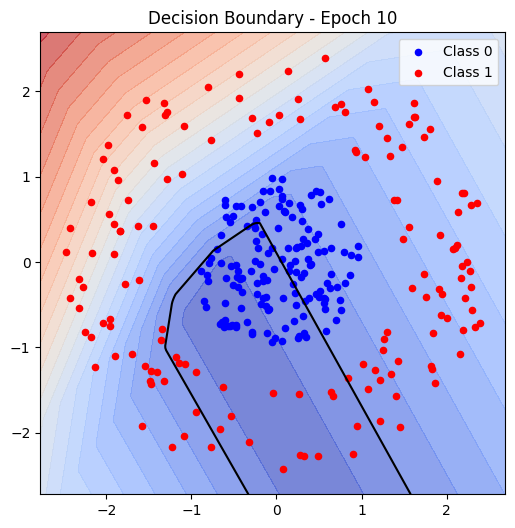

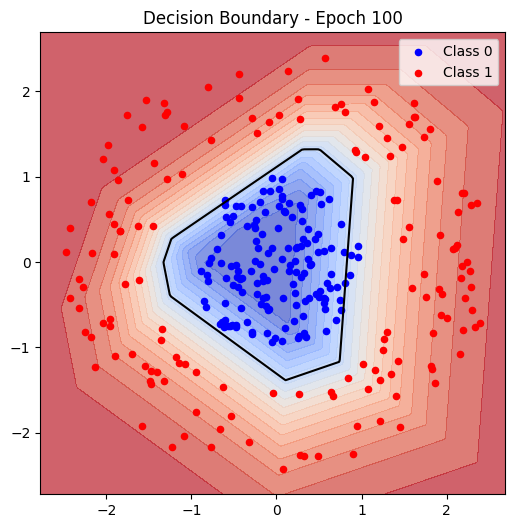

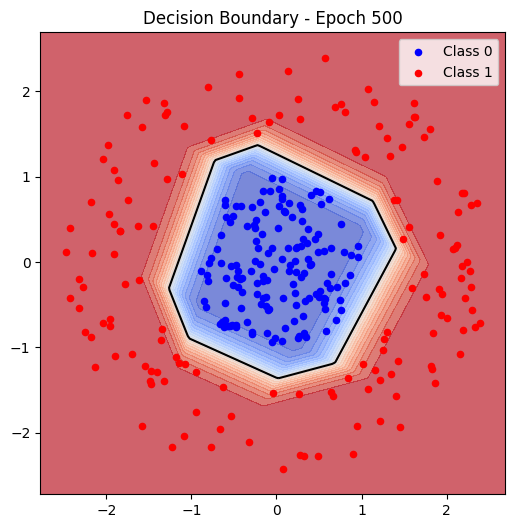

In [33]:
model = ANN()

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

epochs = 500

save_epochs = [10, 100, 500]

for epoch in range(1, epochs + 1):

    # TRAIN
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    # Vẽ boundary
    if epoch in save_epochs:

        plot_boundary(model, epoch)

Nhận xét
Epoch 10

boundary còn khá đơn giản,
gần giống đường thẳng,
model chưa học rõ cấu trúc dữ liệu.

Epoch 100

boundary bắt đầu cong,
ANN học được tính phi tuyến.

Epoch 500

boundary gần thành hình tròn,
bao quanh lớp đĩa ở giữa,
model phân loại rất tốt.